# Toxic Comments Classification - NB

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS


Dataset: JgsawToxic dataset is a dataset of comments from Wikipedia’s talk page edits. It is avaialble at Kaggle (https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data). 


The comments are divided in two classes: toxic and normal.

Algorithme used: NB

Preprocessing techniques used:
* Lowercase
* Remove frequent words
* Remove stop words
* Tokenization (accept all kind of tokens except spaces (carriage returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_validate, cross_val_predict
from matplotlib import pyplot as plt 
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side

# 2. Data Preparation 

In [2]:
# Load training data
df = pd.read_csv('../../Data/train_set3.csv')
df.head()

,Tweet ID,Text,tox
0,1230482808457527297,BREAKING: Many leading Chinese scientists are ...,0.0
1,1244980592615116800,"If China can kill us, they can kill you too @A...",1.0
2,1244899032771604480,Fuck u Chi Na!!! Karma is coming soon !!! The ...,1.0
3,1244895530720710656,Some Chinese are horrible as fuck! #ChinaLiedP...,1.0
4,1244341105879142407,"@ScottGottliebMD you are a ""doctor"" and you be...",1.0


In [3]:
# Load testing data
test = pd.read_csv('../../Data/test_set3.csv')
test.head()

,Tweet ID,Text,tox
0,1230469201325895691,@BangizweNkosi @alfred_cabonena #Commies the s...,1.0
1,1245286806330806273,@LeeooZeng @ChinaDaily Mother Fucking #chinese...,1.0
2,1245502582593912833,@argyleumbrella @business Yep. Fucking MONTHS ...,1.0
3,1230388499792220163,To all the Xbots that couldn’t control your fa...,0.0
4,1241063784501915648,@realDonaldTrump This is the most racist and u...,0.0


# 3. Preprocessing

In [4]:
stop_words = set(stopwords.words('english'))

In [5]:
print(stop_words)

{'out', 'if', 'him', 'ours', 'themselves', 'y', "you've", 'to', 'no', 'couldn', 'only', 'didn', 'me', 'm', 'there', 'by', 'doesn', 'off', 'an', "should've", "haven't", 'needn', "didn't", 'under', 'against', "you're", 'further', 'its', "you'd", 'how', 'more', 'is', 'why', 'yourself', 'but', 'were', 'd', 'you', 'because', 'the', 've', 'haven', 'they', 'has', "mightn't", 'am', 'where', 'won', "wouldn't", "she's", 'for', 'mightn', 'whom', 'and', 'he', 'both', 'that', 's', 'hers', 'over', "shan't", 'will', 'very', 'had', 'shan', "weren't", 'my', 'can', 'ma', 'of', 'then', 'yourselves', "wasn't", 'her', 'between', 'doing', "that'll", 'until', 'should', "isn't", 'weren', "you'll", 'll', 'are', 'ain', 'through', "aren't", 'during', 'at', 'such', 'now', 'do', 'so', 'into', "hasn't", 'mustn', 'about', 'aren', 'each', "couldn't", 'up', 'we', 'down', 'here', "shouldn't", 'did', 'yours', 'some', 'was', 'than', 'herself', 'don', 'myself', 'below', "don't", 'what', 'before', 'i', 'once', 'ourselves',

In [6]:
def convert_lowercase(comment): 

    comment = comment.lower() # Normalize to lowercase 
    
    return comment

In [7]:
# clean and normalize comments
df['Text'] = df['Text'].map(lambda word:convert_lowercase(word))
test['comment_text'] = test['Text'].map(lambda word:convert_lowercase(word))

In [8]:
# find the 10 most frequent words in the train data
dellist1 = pd.Series(' '.join(df['Text']).split()).value_counts()[1:10]
print(dellist1)

to         1167
and         944
of          824
a           786
is          781
chinese     635
you         622
in          606
china       502
dtype: int64


In [9]:
# remove the most frequent words from the train data
dellist1 = list(dellist1.index)
df['Text'] = df['Text'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist1))
df.head()

,Tweet ID,Text,tox
0,1230482808457527297,breaking: many leading scientists are starting...,0.0
1,1244980592615116800,"if can kill us, they can kill too @angusch8961...",1.0
2,1244899032771604480,fuck u chi na!!! karma coming soon !!! the ccp...,1.0
3,1244895530720710656,some are horrible as fuck! #chinaliedpeopledie...,1.0
4,1244341105879142407,"@scottgottliebmd are ""doctor"" believe that shi...",1.0


In [10]:
# find the 10 most frequent words i the test data
dellist2 = pd.Series(' '.join(test['Text']).split()).value_counts()[1:10]
print(dellist2)

to         283
and        204
of         202
is         201
a          189
in         152
Chinese    137
are        115
you        110
dtype: int64


In [11]:
# remove the most frequent words from the test data
dellist2 = list(dellist2.index)
test['Text'] = test['Text'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist2))
test.head()

,Tweet ID,Text,tox,comment_text
0,1230469201325895691,@BangizweNkosi @alfred_cabonena #Commies the s...,1.0,@bangizwenkosi @alfred_cabonena #commies the s...
1,1245286806330806273,@LeeooZeng @ChinaDaily Mother Fucking #chinese...,1.0,@leeoozeng @chinadaily mother fucking #chinese...
2,1245502582593912833,@argyleumbrella @business Yep. Fucking MONTHS ...,1.0,@argyleumbrella @business yep. fucking months ...
3,1230388499792220163,To all the Xbots that couldn’t control your fa...,0.0,to all the xbots that couldn’t control your fa...
4,1241063784501915648,@realDonaldTrump This the most racist unprofes...,0.0,@realdonaldtrump this is the most racist and u...


In [12]:
def clean_text(comment): 

    word_tokens = comment.split(' ') #word_tokenize(comment)
    
    filtered_comment = []  
    # converts the words in word_tokens tand tchecks whether 
    #they are present in stop_words or not
    for w in word_tokens:
        if w not in stop_words:
            filtered_comment.append(w)

    comment = (" ").join(filtered_comment)
    
    return comment

In [13]:
# clean and normalize comments
df['Text'] = df['Text'].map(lambda word:clean_text(word))
test['Text'] = test['Text'].map(lambda word:clean_text(word))

In [14]:
x_train = df['Text']
y_train = df['tox']

#Check shape of data
print(x_train.shape)
print(y_train.shape)

(2104,)
(2104,)


In [15]:
X_test = test['Text']
Y_test = test['tox']

#Check shape of data
print(X_test.shape)
print(Y_test.shape)

(527,)
(527,)


# 3. Classifier training 

### Create pipeline

In [16]:
# create a pipeline
model_pipeline = Pipeline([
                ('tfidf', TfidfVectorizer(lowercase=False, 
                                          token_pattern=r'\S+', max_features=20000)),
                ('clf', MultinomialNB(alpha=0.1))])

In [17]:
# cross validation
metrics = ['accuracy', 'recall', 'f1', 'precision']
result = cross_validate (model_pipeline, x_train, y_train, cv=5, scoring = metrics,  return_estimator=True)

In [18]:
# save models
svc_fit = result['estimator']
i = 0
for model in svc_fit:
    dir_name = "models/Set1_approach#10_" + str(i) + ".sav"
    pickle.dump(model, open(dir_name, 'wb'))
    i = i + 1

### Evaluate metrics

In [19]:
# Model Evaluation metrics for train data
train_accuracy = "%.4f" % (result['test_accuracy'].mean())
train_recall  = "%.4f" % (result['test_recall'].mean())
train_F1_score  = "%.4f" % (result['test_f1'].mean())
train_precision  = "%.4f" % (result['test_precision'].mean())

# Print scores for evaluation metrics
print('Results for train data')
print ('-----------------------')
print('Accuracy score : ', train_accuracy)
print('recall : ', train_recall)
print('F1_score : ' , train_F1_score)
print('precision : ' , train_precision)

Results for train data
-----------------------
Accuracy score :  0.8679
recall :  0.9560
F1_score :  0.8756
precision :  0.8077


# 4. Predictions

### Test set

In [20]:
# predict test data
preds_test = cross_val_predict(model_pipeline, X_test, Y_test, cv=5)

In [21]:
# svm Confusion matrix
print('\n confusion matrix for test data \n')
print((confusion_matrix(Y_test, preds_test)))


 confusion matrix for test data 

[[172  91]
 [ 49 215]]


In [22]:
# svm classification report
print('\n\n classification report for test data \n')
print(classification_report(Y_test, preds_test, target_names=['normal','toxic']))



 classification report for test data 

              precision    recall  f1-score   support

      normal       0.78      0.65      0.71       263
       toxic       0.70      0.81      0.75       264

    accuracy                           0.73       527
   macro avg       0.74      0.73      0.73       527
weighted avg       0.74      0.73      0.73       527



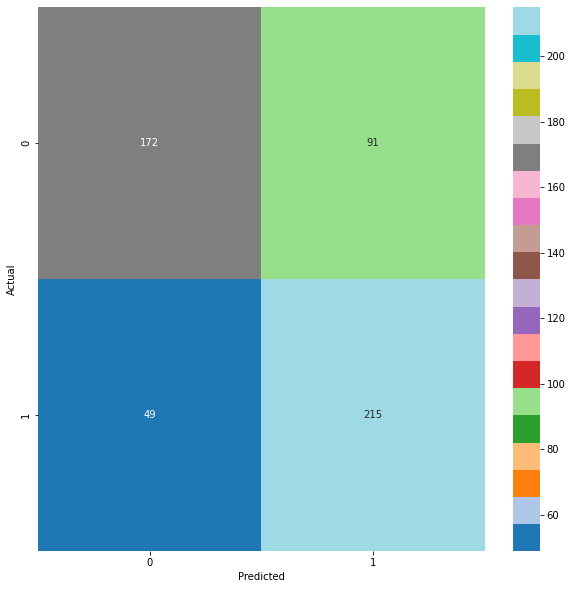

In [23]:
# plot confusion matrix
conf_mat = confusion_matrix(Y_test, preds_test)
fig, ax = plt.subplots(figsize=(10,10))
cmap = "tab20"
sns.heatmap(conf_mat, annot=True, fmt='d',cmap=cmap)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [24]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, preds_test))
test_recall  = "%.4f" % (recall_score(Y_test, preds_test))
test_F1_score  = "%.4f" % (f1_score(Y_test, preds_test))
test_precision  = "%.4f" % (precision_score(Y_test, preds_test))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.7343
recall :  0.8144
F1_score :  0.7544
precision :  0.7026


# 5. Save results to Excel file

In [25]:
# define tarjet
newFile = "../results_NB_set3.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #10', 2:train_accuracy, 3:train_recall, 4:train_F1_score, 5:train_precision, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach
index = 12

# delete row of approach
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)